# 04 — Exploratory Analysis and Experimental Design

This notebook establishes the experimental framework for the modelling stage of the wildfire-risk project and explores the relationships between wildfire occurrence, meteorological conditions and vegetation state.

The analysis is performed at the **5 km grid cell × reference week** level, using the final dataset that combines:

- wildfire occurrence in the following 7 days;
- ERA5-Land meteorological features;
- Sentinel-2 vegetation features based on NDVI and NDMI.

Particular attention is given to class imbalance, temporal patterns, feature distributions, statistical differences between fire and non-fire observations, feature redundancy and missing data.

Because wildfire prediction is inherently temporal, the evaluation strategy must reproduce a realistic forecasting scenario. A random train-test split would allow observations from future years to influence the training process and could lead to overly optimistic estimates of model performance.

For this reason, the data will be divided chronologically, keeping future years completely separate from the data used for model development.

## 1. Dataset overview

Before defining the modelling split, the final dataset is inspected to confirm its temporal coverage, dimensions and annual wildfire prevalence.

This first analysis also helps identify whether the positive-class frequency changes substantially between years, which may affect model evaluation and interpretation.

In [133]:
from pathlib import Path
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
MODEL_PATH = Path("../data/processed/model_dataset_full.parquet")

In [15]:
df = pd.read_parquet(MODEL_PATH)

In [84]:
print(df.columns)

Index(['cell_id', 'reference_date', 'target_end', 'iso_year', 'iso_week',
       'fire_count_week', 'fire_next_7_days', 'era5_pixel_id', 'distance_km',
       'consecutive_dry_days', 'potential_evaporation_sum_7d',
       'precipitation_sum_14d', 'precipitation_sum_30d',
       'precipitation_sum_7d', 'relative_humidity_mean_7d',
       'soil_moisture_change_7d', 'soil_moisture_last_day',
       'soil_moisture_mean_7d', 'solar_radiation_sum_7d', 'temperature_max_7d',
       'temperature_mean_7d', 'vpd_mean_7d', 'water_balance_7d',
       'wind_speed_max_daily_mean_7d', 'wind_speed_mean_7d',
       'vegetation_fraction', 'selected_date', 'image_age_days', 'valid_pct',
       'NDVI_mean', 'NDVI_median', 'NDVI_p10', 'NDVI_p90', 'NDMI_mean',
       'NDMI_median', 'NDMI_p10', 'NDMI_p90', 'vegetation_obs_60d',
       'NDVI_slope_30d', 'NDMI_slope_30d', 'split'],
      dtype='str')


In [20]:
df.head()

,cell_id,reference_date,target_end,iso_year,iso_week,fire_count_week,fire_next_7_days,era5_pixel_id,distance_km,consecutive_dry_days,...,NDVI_median,NDVI_p10,NDVI_p90,NDMI_mean,NDMI_median,NDMI_p10,NDMI_p90,vegetation_obs_60d,NDVI_slope_30d,NDMI_slope_30d
0,PT_0001,2017-05-01,2017-05-07,2017,18,0,0,ERA5_-9.350043_38.750177,11.069334,0.0,...,0.785103,0.254215,0.878637,0.282065,0.326120,0.009856,0.474825,5,-0.014398,-0.015259
1,PT_0001,2017-05-08,2017-05-14,2017,19,0,0,ERA5_-9.350043_38.750177,11.069334,2.0,...,0.753860,0.269171,0.847348,0.327866,0.371156,0.074992,0.495967,6,-0.006217,-0.000559
2,PT_0001,2017-05-15,2017-05-21,2017,20,0,0,ERA5_-9.350043_38.750177,11.069334,2.0,...,0.667916,0.262030,0.753806,0.285879,0.322069,0.057023,0.439072,6,-0.004294,0.006366
3,PT_0001,2017-05-22,2017-05-28,2017,21,0,0,ERA5_-9.350043_38.750177,11.069334,9.0,...,0.761514,0.261339,0.847561,0.304319,0.355304,0.019593,0.496468,6,0.004026,0.016729
4,PT_0001,2017-05-29,2017-06-04,2017,22,0,0,ERA5_-9.350043_38.750177,11.069334,0.0,...,0.636897,0.214698,0.722615,0.252876,0.298748,0.001678,0.423575,8,-0.027068,-0.006240


In [83]:
print(f'Dataset Shape: {df.shape} \n' )
print(f"Reference date interval: \n {df['reference_date'].min()} to {df['reference_date'].max()} \n")
print(f'Observations per year: \n {df.groupby('iso_year').size()}')

Dataset Shape: (875238, 41) 

Reference date interval: 
 2017-05-01 00:00:00 to 2025-10-20 00:00:00 

Observations per year: 
 iso_year
2017    99372
2018    95550
2019    95550
2020    95550
2021    99372
2022    99372
2023    99372
2024    95550
2025    95550
dtype: int64


In [82]:
annual_summary = (
    df.groupby("iso_year")["fire_next_7_days"]
    .agg(
        observations="size",
        positives="sum",
        positive_rate="mean"
    ))

annual_summary["positive_pct"] = (
    annual_summary["positive_rate"] * 100)

annual_summary

,observations,positives,positive_rate,positive_pct
iso_year,,,,
2017,99372,9280,0.093386,9.338647
2018,95550,5973,0.062512,6.251177
2019,95550,6063,0.063454,6.345369
2020,95550,5828,0.060994,6.099424
2021,99372,4514,0.045425,4.542527
2022,99372,5261,0.052942,5.294248
2023,99372,3996,0.040213,4.021253
2024,95550,3880,0.040607,4.060701
2025,95550,5345,0.055939,5.593930


### Annual wildfire prevalence

The dataset is moderately imbalanced, with wildfire-positive cell-weeks representing
only a small fraction of all observations. However, the degree of imbalance is not
constant over time.

Annual wildfire prevalence ranges from approximately **4% to 9%**, with 2017
showing the highest positive rate and 2023–2024 the lowest.

This temporal variation is important for model evaluation because the probability
of observing a wildfire-positive cell-week changes between years. Therefore, model
performance should not be assessed under the assumption that the training and test
sets follow identical distributions.

The difference in the total number of observations between years is expected:
depending on the calendar, the May–October study period contains either 25 or 26
complete reference weeks. Since all 3,822 grid cells are represented in every week,
this does not indicate missing observations.

These results further motivate the use of a **chronological train-validation-test
split** instead of a random split.

In [81]:
df['split'] = None

df.loc[df["iso_year"].between(2017, 2022), "split"] = 'train'
df.loc[df["iso_year"] == 2023, "split"] = 'validation'
df.loc[df["iso_year"].between(2024, 2025), "split"] = 'test'

split_summary = (
    df.groupby("split")["fire_next_7_days"]
    .agg(
        observations="size",
        positives="sum",
        positive_rate="mean"
    )
)

split_summary["positive_pct"] = split_summary["positive_rate"] * 100

split_summary

,observations,positives,positive_rate,positive_pct
split,,,,
test,191100,9225,0.048273,4.827316
train,584766,36919,0.063135,6.313466
validation,99372,3996,0.040213,4.021253


## 2. Temporal experimental split

A chronological split is used to preserve the temporal structure of the wildfire
prediction problem and to approximate a realistic deployment scenario, where models
are trained using historical observations and evaluated on future periods.

The dataset is divided as follows:

- **Training set:** 2017–2022
- **Validation set:** 2023
- **Test set:** 2024–2025

The validation year will be used for model selection, hyperparameter tuning and
decision-threshold selection. The test period will remain untouched until the final
comparison of the modelling approaches.

The wildfire-positive rate differs between the three partitions, decreasing from
approximately **6.31% in training** to **4.02% in validation** and **4.83% in the
test period**. This indicates temporal variation in the class prior and reinforces
the importance of evaluating the models on future years rather than using a random
train-test split.

Importantly, the test set must not be used to select features, tune
hyperparameters or modify modelling decisions.

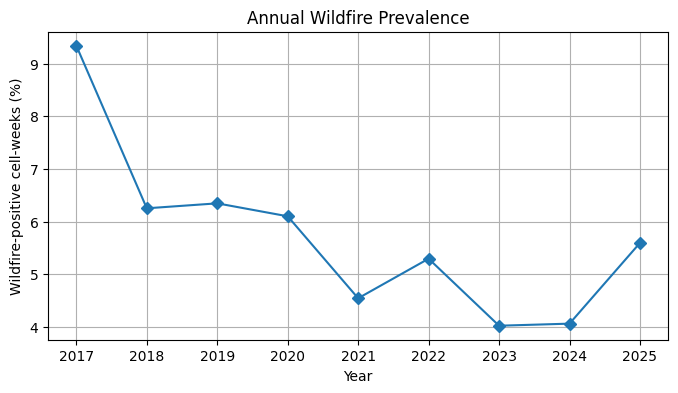

In [74]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    annual_summary.index,
    annual_summary["positive_pct"],
    marker="D"
)

ax.set_xlabel("Year")
ax.set_ylabel("Wildfire-positive cell-weeks (%)")
ax.set_title("Annual Wildfire Prevalence")
ax.grid()

plt.show()

### Interpretation

Wildfire prevalence varies substantially across the study period. The proportion of
wildfire-positive cell-weeks is highest in 2017 (**9.34%**) and subsequently remains
mostly between approximately **4% and 6%**.

The training period therefore contains a higher overall wildfire prevalence
(**6.31%**) than both the validation (**4.02%**) and test (**4.83%**) periods.

This temporal variation in the target distribution represents a form of
**class-prior shift**: the frequency of the positive class changes over time.
Consequently, a model evaluated on future years must remain effective under wildfire
prevalence levels that differ from those observed during training.

This also highlights why accuracy alone would be an inappropriate evaluation metric.
Given the relatively low frequency of positive observations, subsequent model
evaluation will place greater emphasis on metrics designed for imbalanced
classification, particularly **precision, recall and PR-AUC**.

## 3. Seasonal wildfire patterns

Wildfire occurrence in Portugal is strongly seasonal. Before analysing individual
meteorological or vegetation predictors, it is therefore important to understand how
the target itself varies throughout the May–October study period.

To avoid using information from the future test period when making modelling
decisions, the following exploratory analyses are performed using the **training
period only (2017–2022)**.

Wildfire prevalence is first examined by the month of the weekly reference date.
Because each observation represents a complete 7-day prediction window beginning on
a Monday, the month corresponds to the month containing the reference date.

In [75]:
train_df = df[df["split"] == "train"].copy()

In [85]:
train_df["month"] = train_df["reference_date"].dt.month

month_names = {
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
}

train_df["month_name"] = train_df["month"].map(month_names)

monthly_summary = (
    train_df.groupby('month_name')['fire_next_7_days']
    .agg(
            observations="size",
            positives="sum",
            positive_rate="mean"
        )
    )
    
monthly_summary["positive_pct"] = monthly_summary["positive_rate"] * 100

month_order = [
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
]

monthly_summary = monthly_summary.reindex(month_order)

monthly_summary

,observations,positives,positive_rate,positive_pct
month_name,,,,
May,103194,4633,0.044896,4.489602
June,95550,5066,0.053019,5.301936
July,103194,8196,0.079423,7.942322
August,103194,8813,0.085402,8.540225
September,95550,5655,0.059184,5.918367
October,84084,4556,0.054184,5.418391


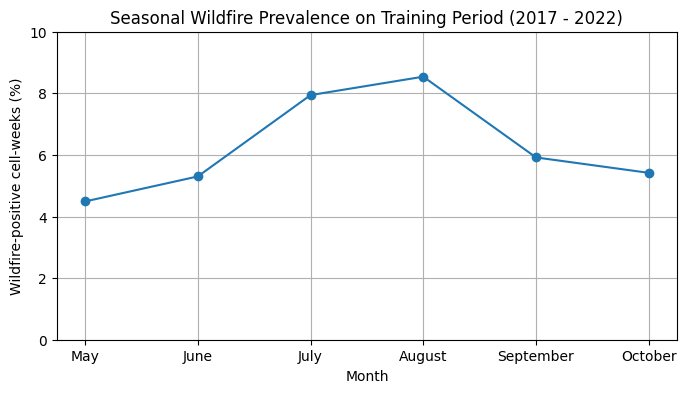

In [93]:
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(
    monthly_summary.index,
    monthly_summary['positive_pct'],
    marker='o'
)

ax.set_ylim(0, 10)
ax.set_xlabel("Month")
ax.set_ylabel("Wildfire-positive cell-weeks (%)")
ax.set_title("Seasonal Wildfire Prevalence on Training Period (2017 - 2022)")
ax.grid()

### Interpretation

Wildfire occurrence shows a clear seasonal pattern during the training period.

The proportion of wildfire-positive cell-weeks increases from **4.49% in May**
to **5.30% in June**, before rising substantially during the summer months.
Prevalence reaches **7.94% in July** and peaks at **8.54% in August**.

The rate subsequently decreases to **5.92% in September** and **5.42% in October**.

This pattern indicates that the probability of wildfire occurrence is strongly
dependent on the time of year. However, the observed seasonal association may
reflect underlying changes in meteorological conditions and vegetation state
rather than an independent effect of calendar month itself.

The next step therefore evaluates whether the association between month and
wildfire occurrence is statistically detectable and, more importantly, estimates
its magnitude.

In [96]:
contingency_table = pd.crosstab(
    train_df["month_name"],
    train_df["fire_next_7_days"]
).reindex(month_order)

contingency_table

fire_next_7_days,0,1
month_name,,
May,98561,4633
June,90484,5066
July,94998,8196
August,94381,8813
September,89895,5655
October,79528,4556


In [ ]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.3e}")

n = contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * min(
            contingency_table.shape[0] - 1,
            contingency_table.shape[1] - 1
        )))

print(f" \nCramér's V: {cramers_v:.4f}")

Chi-square statistic: 2212.718
Degrees of freedom: 5
P-value: 0.000e+00
 
Cramér's V: 0.0615


### Statistical association between seasonality and wildfire occurrence

A Chi-square test of independence was used to assess whether wildfire occurrence
is associated with the month of the year during the training period.

The hypotheses were:

- **H₀:** wildfire occurrence and month are independent;
- **H₁:** wildfire occurrence and month are associated.

The test produced:

- χ² = **2212.72**
- degrees of freedom = **5**
- p-value < **0.001**
- Cramér's V = **0.0615**

The null hypothesis of independence is therefore rejected, indicating a clear
statistical association between month and wildfire occurrence.

However, the magnitude of the association is small according to Cramér's V.
This distinction is particularly important given the very large sample size:
with more than half a million training observations, even relatively small
differences can produce extremely small p-values.

Therefore, the results suggest that **seasonality contains predictive
information, but calendar month alone explains only a limited part of wildfire
occurrence**. Meteorological conditions and vegetation state are likely to
provide substantially more specific information about short-term wildfire risk.

The Chi-square result should also be interpreted as exploratory evidence rather
than strict inferential proof because repeated observations from the same grid
cells and neighbouring weeks are not fully independent.

In [105]:
weather_features = [
    "temperature_max_7d",
    "relative_humidity_mean_7d",
    "vpd_mean_7d",
    "precipitation_sum_7d",
]

In [106]:
weather_summary = (
    train_df
    .groupby("fire_next_7_days")[weather_features]
    .agg(["mean", "median", "std"])
)

weather_summary

temperature_max_7d                       \
                               mean     median       std   
fire_next_7_days                                           
0                         29.714040  29.717477  5.236324   
1                         29.477801  29.614389  4.752617   

                 relative_humidity_mean_7d                       vpd_mean_7d  \
                                      mean     median        std        mean   
fire_next_7_days                                                               
0                                60.761941  61.499911  13.619380    1.040630   
1                                63.839669  65.951344  12.563491    0.942104   

                                     precipitation_sum_7d                       
                    median       std                 mean    median        std  
fire_next_7_days                                                                
0                 0.910206  0.585371             6.701362  1.153315  14.037665  
1                 0.816769  0.504793             4.919959  0.752349  11.310860

### Controlling for seasonal confounding

The previous descriptive comparison pooled observations from the entire May–October
period. This can obscure the relationship between weather conditions and wildfire
occurrence because both wildfire prevalence and meteorological conditions vary
substantially throughout the season.

For example, comparing all fire-positive and fire-negative observations together
may partly capture differences between months rather than differences associated
with wildfire occurrence itself.

To reduce this seasonal confounding, the weather variables are now compared
between fire-positive and fire-negative observations **within each month**.

The analysis begins with vapour pressure deficit (VPD), an atmospheric dryness
indicator that is expected to be relevant to vegetation moisture stress and
wildfire risk.

In [123]:
vpd_summary = (
    train_df
    .groupby(["month_name", "fire_next_7_days"])["vpd_mean_7d"]
    .mean()
    .unstack()
    .reindex(month_order))

vpd_summary.columns = ["no_fire_mean", "fire_mean"]

vpd_summary["difference"] = (
    vpd_summary["fire_mean"]
    - vpd_summary["no_fire_mean"]
)

vpd_summary

,no_fire_mean,fire_mean,difference
month_name,,,
May,0.714485,0.631949,-0.082536
June,0.978396,0.885398,-0.092998
July,1.278805,1.091017,-0.187787
August,1.396320,1.098315,-0.298005
September,1.021059,0.928060,-0.092999
October,0.831132,0.767926,-0.063206


### VPD differences within the fire season

After controlling for month, wildfire-positive observations continue to show lower
mean VPD than wildfire-negative observations across all months of the training period.

The difference is particularly pronounced during July and August.

However, this result should not be interpreted as evidence that lower atmospheric
dryness increases wildfire risk. Absolute VPD varies geographically, while wildfire
occurrence is also spatially heterogeneous across Portugal.

Consequently, the observed relationship may reflect **spatial confounding**:
regions with different baseline climates, vegetation characteristics and wildfire
frequencies are being compared simultaneously.

To distinguish geographical climate differences from short-term weather anomalies,
the next analysis compares VPD relative to the typical conditions of the **same
grid cell and calendar month**.

In [124]:
train_df["vpd_cell_month_mean"] = (
    train_df
    .groupby(["cell_id", "month"])["vpd_mean_7d"]
    .transform("mean")
)

train_df["vpd_anomaly"] = (
    train_df["vpd_mean_7d"]
    - train_df["vpd_cell_month_mean"]
)

vpd_anomaly_summary = (
    train_df
    .groupby("fire_next_7_days")["vpd_anomaly"]
    .agg(
        mean="mean",
        median="median",
        std="std"
    )
)

vpd_anomaly_summary

,mean,median,std
fire_next_7_days,,,
0,-0.004581,-0.074404,0.395872
1,0.067982,-0.007564,0.353879


### Spatially and seasonally adjusted VPD

The comparison based on absolute VPD values initially suggested that
wildfire-positive observations occurred under lower VPD conditions than
wildfire-negative observations.

However, absolute VPD also varies geographically and seasonally. To reduce this
confounding, each weekly VPD observation was centred relative to the average VPD
of the same **grid cell and calendar month** during the training period:

$$
VPD_{\text{anomaly}}
=
VPD_{\text{week}}
-
\overline{VPD}_{\text{cell,month}}
$$

Positive values therefore represent weeks that are atmospherically drier than
usual for that location and time of year.

After this adjustment, the direction of the relationship reverses. Wildfire-positive
observations have a mean VPD anomaly of approximately **+0.068**, compared with
approximately **−0.005** for wildfire-negative observations.

The median anomaly is also higher for wildfire-positive observations
(**−0.008 vs −0.074**).

This sign reversal indicates that the initial comparison of absolute VPD was
affected by spatial and seasonal confounding. Relative to local seasonal
conditions, wildfire-positive weeks tend to occur under **higher-than-usual
atmospheric dryness**.

This does not establish a causal effect of VPD, but it suggests that relative atmospheric dryness may contain information associated with short-term wildfire occurrence.

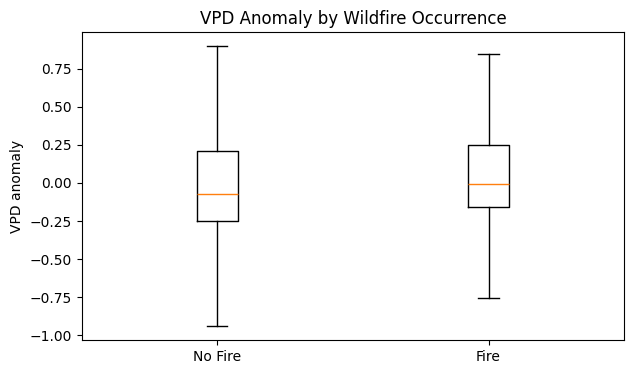

In [131]:
no_fire_vpd = train_df.loc[
    train_df["fire_next_7_days"] == 0,
    "vpd_anomaly"
]

fire_vpd = train_df.loc[
    train_df["fire_next_7_days"] == 1,
    "vpd_anomaly"
]

fig, ax = plt.subplots(figsize=(7, 4))

ax.boxplot(
    [no_fire_vpd, fire_vpd],
    tick_labels=["No Fire", "Fire"],
    showfliers=False
)

ax.set_ylabel("VPD anomaly")
ax.set_title("VPD Anomaly by Wildfire Occurrence")

plt.show()

### Visual comparison of VPD anomalies

The distribution of VPD anomalies is shifted upward for wildfire-positive
observations.

The median VPD anomaly is closer to zero for wildfire-positive weeks, while
wildfire-negative observations tend to show more negative anomalies.

However, the two distributions overlap substantially. This suggests that VPD
anomaly alone is unlikely to provide strong class separation, even if the
difference between the groups is statistically detectable.

A formal statistical test and an effect-size measure are therefore required to
distinguish statistical significance from practical magnitude.

In [134]:
u_stat, p_value = mannwhitneyu(
    fire_vpd,
    no_fire_vpd,
    alternative="two-sided"
)

n1 = len(fire_vpd)
n2 = len(no_fire_vpd)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print(f"Mann-Whitney U: {u_stat:,.0f}")
print(f"P-value: {p_value:.3e}")
print(f"Rank-biserial correlation: {rank_biserial:.4f}")

Mann-Whitney U: 11,460,493,372
P-value: 0.000e+00
Rank-biserial correlation: 0.1332


### Statistical comparison of VPD anomalies

A Mann–Whitney U test was used to compare VPD anomalies between wildfire-positive
and wildfire-negative observations.

The test produced:

- Mann–Whitney U = **11,460,493,372**
- p-value < **0.001**
- rank-biserial correlation = **0.1332**

The difference between the two distributions is therefore statistically detectable.
However, the effect size is small.

This result is consistent with the substantial overlap observed in the boxplot:
wildfire-positive weeks tend to experience higher-than-usual atmospheric dryness
relative to the same grid cell and calendar month, but VPD anomaly alone does not
strongly separate wildfire-positive from wildfire-negative observations.

The very small p-value should be interpreted cautiously because of the large sample
size and the repeated observations from the same grid cells. The effect-size estimate
is therefore more informative for assessing practical magnitude.

## 4. Vegetation condition and wildfire occurrence

Sentinel-2 vegetation indices provide information that is not directly represented
by meteorological observations.

Two indices are considered initially:

- **NDVI** (*Normalized Difference Vegetation Index*), which primarily reflects
  vegetation greenness and photosynthetic activity;
- **NDMI** (*Normalized Difference Moisture Index*), which is more directly related
  to vegetation and canopy moisture conditions.

Lower values may indicate reduced vegetation vigour or moisture availability,
although absolute index values also vary strongly with vegetation type, location
and season.

As with the weather analysis, the first step is a descriptive comparison between
wildfire-positive and wildfire-negative observations in the training period.
Subsequent analyses will control for spatial and seasonal differences using
cell-specific anomalies.

In [140]:
vegetation_features = [
    "NDVI_mean",
    "NDMI_mean",
]

ndvi_ndmi_summary = (
    train_df.groupby("fire_next_7_days")[vegetation_features]
    .agg(['mean' , 'median' , 'std'])
)

ndvi_ndmi_summary

NDVI_mean                     NDMI_mean                    
                      mean    median       std      mean    median       std
fire_next_7_days                                                            
0                 0.465442  0.463386  0.136976 -0.006801 -0.016728  0.126573
1                 0.525112  0.552230  0.128503  0.053393  0.069746  0.114920

### Absolute vegetation-index differences

Wildfire-positive observations show higher absolute NDVI and NDMI values than
wildfire-negative observations.

Mean NDVI increases from approximately **0.465** in wildfire-negative observations
to **0.525** in wildfire-positive observations, while mean NDMI increases from
approximately **−0.007** to **0.053**.

These results should not be interpreted as evidence that greener or wetter
vegetation directly increases short-term wildfire risk. Absolute vegetation indices
vary substantially across land-cover types and geographic regions.

Areas with greater vegetation cover and biomass may simultaneously exhibit higher
NDVI/NDMI values and greater wildfire occurrence, creating spatial confounding.

To better isolate short-term departures from typical vegetation conditions, the
indices are therefore analysed relative to the usual conditions of the same grid
cell and calendar month.

In [141]:
train_df["NDVI_cell_month_mean"] = (
    train_df
    .groupby(["cell_id", "month"])["NDVI_mean"]
    .transform("mean")
)

train_df["NDMI_cell_month_mean"] = (
    train_df
    .groupby(["cell_id", "month"])["NDMI_mean"]
    .transform("mean")
)

train_df["NDVI_anomaly"] = (
    train_df["NDVI_mean"]
    - train_df["NDVI_cell_month_mean"]
)

train_df["NDMI_anomaly"] = (
    train_df["NDMI_mean"]
    - train_df["NDMI_cell_month_mean"]
)

vegetation_anomaly_summary = (
    train_df
    .groupby("fire_next_7_days")[["NDVI_anomaly", "NDMI_anomaly"]]
    .agg(["mean", "median", "std", "count"])
)

vegetation_anomaly_summary

NDVI_anomaly                             NDMI_anomaly  \
                         mean    median       std   count         mean   
fire_next_7_days                                                         
0                    0.000274  0.000519  0.045570  535437     0.000303   
1                   -0.004006 -0.001876  0.038157   36639    -0.004433   

                                              
                    median       std   count  
fire_next_7_days                              
0                 0.000108  0.042702  535437  
1                -0.003887  0.035339   36639

### Spatially and seasonally adjusted vegetation condition

Absolute NDVI and NDMI values are strongly influenced by location, vegetation type
and season. To reduce these sources of confounding, both indices were centred relative
to the average value observed for the same **grid cell and calendar month** during
the training period.

Negative anomalies therefore indicate vegetation conditions below the typical level
for that location and time of year.

After this adjustment, wildfire-positive observations show slightly lower vegetation
indices than wildfire-negative observations:

- mean NDVI anomaly: approximately **−0.0040** for wildfire-positive observations;
- mean NDMI anomaly: approximately **−0.0044** for wildfire-positive observations.

Wildfire-negative observations are centred close to zero for both indices.

The direction of these differences is consistent with the hypothesis that wildfire
occurrence may be associated with vegetation that is slightly less green and less
moist than usual for its local seasonal baseline.

However, the differences are small relative to the variability of the indices.
Formal statistical tests and effect-size estimates are therefore required before
assessing their practical importance.

Observations without valid Sentinel-2 measurements are excluded automatically from
these comparisons.

In [146]:
no_fire_ndvi = train_df.loc[
    train_df["fire_next_7_days"] == 0,
    "NDVI_anomaly"
].dropna()

fire_ndvi = train_df.loc[
    train_df["fire_next_7_days"] == 1,
    "NDVI_anomaly"
].dropna()

no_fire_ndmi = train_df.loc[
    train_df["fire_next_7_days"] == 0,
    "NDMI_anomaly"
].dropna()

fire_ndmi = train_df.loc[
    train_df["fire_next_7_days"] == 1,
    "NDMI_anomaly"
].dropna()

In [149]:
u_stat, p_value = mannwhitneyu(
    fire_ndvi,
    no_fire_ndvi,
    alternative="two-sided"
)

n1 = len(fire_ndvi)
n2 = len(no_fire_ndvi)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print("NDVI")
print(f"Mann-Whitney U: {u_stat:,.0f}")
print(f"P-value: {p_value:.3e}")
print(f"Rank-biserial correlation: {rank_biserial:.4f}")

NDVI
Mann-Whitney U: 9,288,973,032
P-value: 7.876e-65
Rank-biserial correlation: -0.0530


In [150]:
u_stat, p_value = mannwhitneyu(
    fire_ndmi,
    no_fire_ndmi,
    alternative="two-sided"
)

n1 = len(fire_ndmi)
n2 = len(no_fire_ndmi)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print("NDMI")
print(f"Mann-Whitney U: {u_stat:,.0f}")
print(f"P-value: {p_value:.3e}")
print(f"Rank-biserial correlation: {rank_biserial:.4f}")

NDMI
Mann-Whitney U: 9,132,738,560
P-value: 2.466e-108
Rank-biserial correlation: -0.0689


### Statistical comparison of vegetation anomalies

Mann–Whitney U tests were used to compare NDVI and NDMI anomalies between
wildfire-positive and wildfire-negative observations.

The results were:

| Feature | Mann–Whitney U | p-value | Rank-biserial correlation |
|---|---:|---:|---:|
| NDVI anomaly | 9,288,973,032 | < 0.001 | -0.0530 |
| NDMI anomaly | 9,132,738,560 | < 0.001 | -0.0689 |

Both differences are statistically detectable, with wildfire-positive observations
tending to exhibit lower vegetation-index anomalies.

However, the corresponding effect sizes are very small. This indicates substantial
overlap between wildfire-positive and wildfire-negative observations and suggests
that neither vegetation index alone is sufficient to discriminate wildfire risk.

NDMI shows a slightly stronger association than NDVI, which is consistent with its
greater sensitivity to vegetation moisture conditions.

As in the previous analyses, the extremely small p-values should not be interpreted
independently of effect size, particularly given the large sample size and repeated
observations from the same grid cells.

In [151]:
trend_features = [
    "NDVI_slope_30d",
    "NDMI_slope_30d",
]

In [154]:
trend_summary = (
    train_df
    .groupby("fire_next_7_days")[trend_features]
    .agg(["mean", "median", "std", "count"])
)

trend_summary

NDVI_slope_30d                             NDMI_slope_30d  \
                           mean    median       std   count           mean   
fire_next_7_days                                                             
0                     -0.022029 -0.013952  0.056485  525748      -0.023266   
1                     -0.020869 -0.015529  0.047450   36140      -0.023857   

                                              
                    median       std   count  
fire_next_7_days                              
0                -0.015323  0.052141  525748  
1                -0.019915  0.044422   36140

### Vegetation trends before wildfire occurrence

The 30-day vegetation trends provide a different perspective from the absolute
NDVI and NDMI levels.

For NDVI, the differences between wildfire-positive and wildfire-negative
observations are small and not entirely consistent between the mean and median.
The wildfire-positive group has a slightly less negative mean slope, but a more
negative median slope.

For NDMI, the pattern is more consistent. Wildfire-positive observations show a
more negative median NDMI slope (**−0.0199**) than wildfire-negative observations
(**−0.0153**), suggesting a somewhat faster decline in vegetation moisture before
wildfire occurrence.

These differences remain small relative to the variability of the slopes and
should therefore not be interpreted as strong class separation.

As with the previous vegetation analyses, seasonal and spatial differences may
still influence the raw slope values. The trends are therefore adjusted relative
to the typical slope of the same grid cell and calendar month before formal
statistical testing.

In [155]:
train_df["NDVI_slope_cell_month_mean"] = (
    train_df
    .groupby(["cell_id", "month"])["NDVI_slope_30d"]
    .transform("mean")
)

train_df["NDMI_slope_cell_month_mean"] = (
    train_df
    .groupby(["cell_id", "month"])["NDMI_slope_30d"]
    .transform("mean")
)

train_df["NDVI_slope_anomaly"] = (
    train_df["NDVI_slope_30d"]
    - train_df["NDVI_slope_cell_month_mean"]
)

train_df["NDMI_slope_anomaly"] = (
    train_df["NDMI_slope_30d"]
    - train_df["NDMI_slope_cell_month_mean"]
)

In [157]:
trend_anomaly_summary = (
    train_df
    .groupby("fire_next_7_days")[["NDVI_slope_anomaly", "NDMI_slope_anomaly"]]
    .agg(["mean", "median", "std", "count"])
)

trend_anomaly_summary

NDVI_slope_anomaly                              \
                               mean    median       std   count   
fire_next_7_days                                                  
0                          0.000221 -0.000167  0.033660  525748   
1                         -0.003219 -0.002793  0.027282   36140   

                 NDMI_slope_anomaly                              
                               mean    median       std   count  
fire_next_7_days                                                 
0                          0.000197  0.000243  0.031261  525748  
1                         -0.002864 -0.002328  0.024676   36140

### Adjusted vegetation trends

After controlling for the typical behaviour of each grid cell and calendar month,
wildfire-positive observations show slightly more negative NDVI and NDMI trend
anomalies.



Wildfire-positive observations show:

- a mean NDVI slope anomaly of approximately **−0.0032**;
- a mean NDMI slope anomaly of approximately **−0.0029**.

Wildfire-negative observations remain centred close to zero for both variables.

The average differences are small (approximately 0.003 index units over a 30-day
trend scale) relative to the variability of the slope features. Therefore, these
results should be interpreted as a weak directional signal rather than evidence
of substantial vegetation deterioration before wildfire occurrence.

The magnitude of the differences remains small compared with the overall variability
of the slope features, so formal effect-size estimation is required before drawing
conclusions about practical importance.

In [158]:
trend_anomaly_features = [
    "NDVI_slope_anomaly",
    "NDMI_slope_anomaly",
]

for feature in trend_anomaly_features:
    no_fire = train_df.loc[
        train_df["fire_next_7_days"] == 0,
        feature
    ].dropna()

    fire = train_df.loc[
        train_df["fire_next_7_days"] == 1,
        feature
    ].dropna()

    u_stat, p_value = mannwhitneyu(
        fire,
        no_fire,
        alternative="two-sided"
    )

    n1 = len(fire)
    n2 = len(no_fire)

    rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    print(feature)
    print(f"Mann-Whitney U: {u_stat:,.0f}")
    print(f"P-value: {p_value:.3e}")
    print(f"Rank-biserial correlation: {rank_biserial:.4f}")
    print()

NDVI_slope_anomaly
Mann-Whitney U: 8,842,052,145
P-value: 6.513e-108
Rank-biserial correlation: -0.0693

NDMI_slope_anomaly
Mann-Whitney U: 8,776,075,174
P-value: 3.246e-130
Rank-biserial correlation: -0.0762



### Statistical comparison of vegetation-trend anomalies

Mann–Whitney U tests were used to compare the adjusted 30-day vegetation trends
between wildfire-positive and wildfire-negative observations.

The results were:

| Feature | Mann–Whitney U | p-value | Rank-biserial correlation |
|---|---:|---:|---:|
| NDVI slope anomaly | 8,842,052,145 | < 0.001 | -0.0693 |
| NDMI slope anomaly | 8,776,075,174 | < 0.001 | -0.0762 |

Both vegetation-trend anomalies are statistically different between the two groups,
with wildfire-positive observations tending to exhibit more negative trends.

The effect sizes remain small, indicating substantial overlap between wildfire-positive
and wildfire-negative observations. Nevertheless, the trend features show slightly
stronger associations than the corresponding NDVI and NDMI level anomalies.

NDMI slope anomaly exhibits the strongest association among the analysed vegetation
features. This is consistent with the hypothesis that a recent deterioration in
vegetation moisture may contain information relevant to short-term wildfire risk.

These results should be interpreted as evidence of a weak but consistent association,
rather than strong individual predictive power.

In [159]:
# Soil moisture anomaly relative to the same grid cell and calendar month
train_df["soil_moisture_cell_month_mean"] = (
    train_df
    .groupby(["cell_id", "month"])["soil_moisture_mean_7d"]
    .transform("mean")
)

train_df["soil_moisture_anomaly"] = (
    train_df["soil_moisture_mean_7d"]
    - train_df["soil_moisture_cell_month_mean"]
)

# Descriptive comparison
soil_moisture_summary = (
    train_df
    .groupby("fire_next_7_days")["soil_moisture_anomaly"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        count="count"
    )
)

soil_moisture_summary

,mean,median,std,count
fire_next_7_days,,,,
0,0.000848,-0.004334,0.051711,547847
1,-0.012583,-0.011038,0.049885,36919


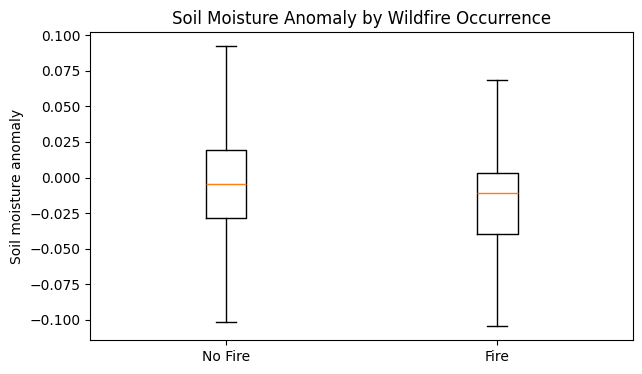

In [160]:
no_fire_soil = train_df.loc[
    train_df["fire_next_7_days"] == 0,
    "soil_moisture_anomaly"
].dropna()

fire_soil = train_df.loc[
    train_df["fire_next_7_days"] == 1,
    "soil_moisture_anomaly"
].dropna()

fig, ax = plt.subplots(figsize=(7, 4))

ax.boxplot(
    [no_fire_soil, fire_soil],
    tick_labels=["No Fire", "Fire"],
    showfliers=False
)

ax.set_ylabel("Soil moisture anomaly")
ax.set_title("Soil Moisture Anomaly by Wildfire Occurrence")

plt.show()

In [161]:
u_stat, p_value = mannwhitneyu(
    fire_soil,
    no_fire_soil,
    alternative="two-sided"
)

n1 = len(fire_soil)
n2 = len(no_fire_soil)

rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print(f"Mann-Whitney U: {u_stat:,.0f}")
print(f"P-value: {p_value:.3e}")
print(f"Rank-biserial correlation: {rank_biserial:.4f}")

Mann-Whitney U: 8,681,943,510
P-value: 0.000e+00
Rank-biserial correlation: -0.1415


### Soil moisture anomalies and wildfire occurrence

Soil moisture was also evaluated relative to the typical conditions of the same
grid cell and calendar month.

Wildfire-positive observations exhibit a lower mean soil-moisture anomaly
(**−0.0126**) than wildfire-negative observations (**+0.0008**), indicating that
wildfires tend to occur during weeks in which soil moisture is below its local
seasonal baseline.

A Mann–Whitney U test produced:

- Mann–Whitney U = **8,681,943,510**
- p-value < **0.001**
- rank-biserial correlation = **−0.1415**

The difference is statistically detectable and the effect size remains small,
although it is stronger than the individual vegetation-index effects observed
previously.

The substantial overlap between the two distributions indicates that soil
moisture anomaly alone cannot separate wildfire-positive and wildfire-negative
observations. Nevertheless, the direction and magnitude of the association
suggest that anomalously dry soil conditions may contribute useful information
to short-term wildfire-risk modelling.

As with the previous statistical analyses, the very large sample size and
repeated observations from the same grid cells require cautious interpretation
of the p-value.

## 5. Feature correlation and redundancy

Before model development, relationships between the candidate predictors are
examined to identify potentially redundant information.

This is particularly relevant for the Logistic Regression model, where strongly
correlated predictors can make coefficient estimates unstable and complicate
interpretation.

Spearman correlation is used as an initial measure of association because several
meteorological and vegetation variables are non-normally distributed and may have
monotonic but non-linear relationships.

Only the training period is used in this analysis to avoid incorporating information
from the validation or test periods into modelling decisions.

In [163]:
exclude_cols = [
    "cell_id",
    "reference_date",
    "target_end",
    "iso_year",
    "iso_week",
    "fire_count_week",
    "fire_next_7_days",
    "era5_pixel_id",
    "distance_km",
    "selected_date",
    "image_age_days",
    "valid_pct",
    "vegetation_obs_60d",
]

In [164]:
candidate_features = [
    col for col in train_df.columns
    if col not in exclude_cols
    and col not in [
        "split",
        "month",
        "month_name",
        "vpd_cell_month_mean",
        "vpd_anomaly",
        "NDVI_cell_month_mean",
        "NDMI_cell_month_mean",
        "NDVI_anomaly",
        "NDMI_anomaly",
        "NDVI_slope_cell_month_mean",
        "NDMI_slope_cell_month_mean",
        "NDVI_slope_anomaly",
        "NDMI_slope_anomaly",
        "soil_moisture_cell_month_mean",
        "soil_moisture_anomaly",
    ]
]

print(len(candidate_features))
print(candidate_features)

27
['consecutive_dry_days', 'potential_evaporation_sum_7d', 'precipitation_sum_14d', 'precipitation_sum_30d', 'precipitation_sum_7d', 'relative_humidity_mean_7d', 'soil_moisture_change_7d', 'soil_moisture_last_day', 'soil_moisture_mean_7d', 'solar_radiation_sum_7d', 'temperature_max_7d', 'temperature_mean_7d', 'vpd_mean_7d', 'water_balance_7d', 'wind_speed_max_daily_mean_7d', 'wind_speed_mean_7d', 'vegetation_fraction', 'NDVI_mean', 'NDVI_median', 'NDVI_p10', 'NDVI_p90', 'NDMI_mean', 'NDMI_median', 'NDMI_p10', 'NDMI_p90', 'NDVI_slope_30d', 'NDMI_slope_30d']


### Correlation analysis

The candidate predictor set contains multiple variables describing related physical
processes. Strong correlations are therefore expected, particularly among
meteorological variables measured over different accumulation windows and among
summary statistics derived from the same Sentinel-2 index.

Spearman rank correlation is used to identify monotonic relationships and potential
feature redundancy.

The analysis focuses first on strongly correlated feature pairs before examining
the complete correlation structure visually.

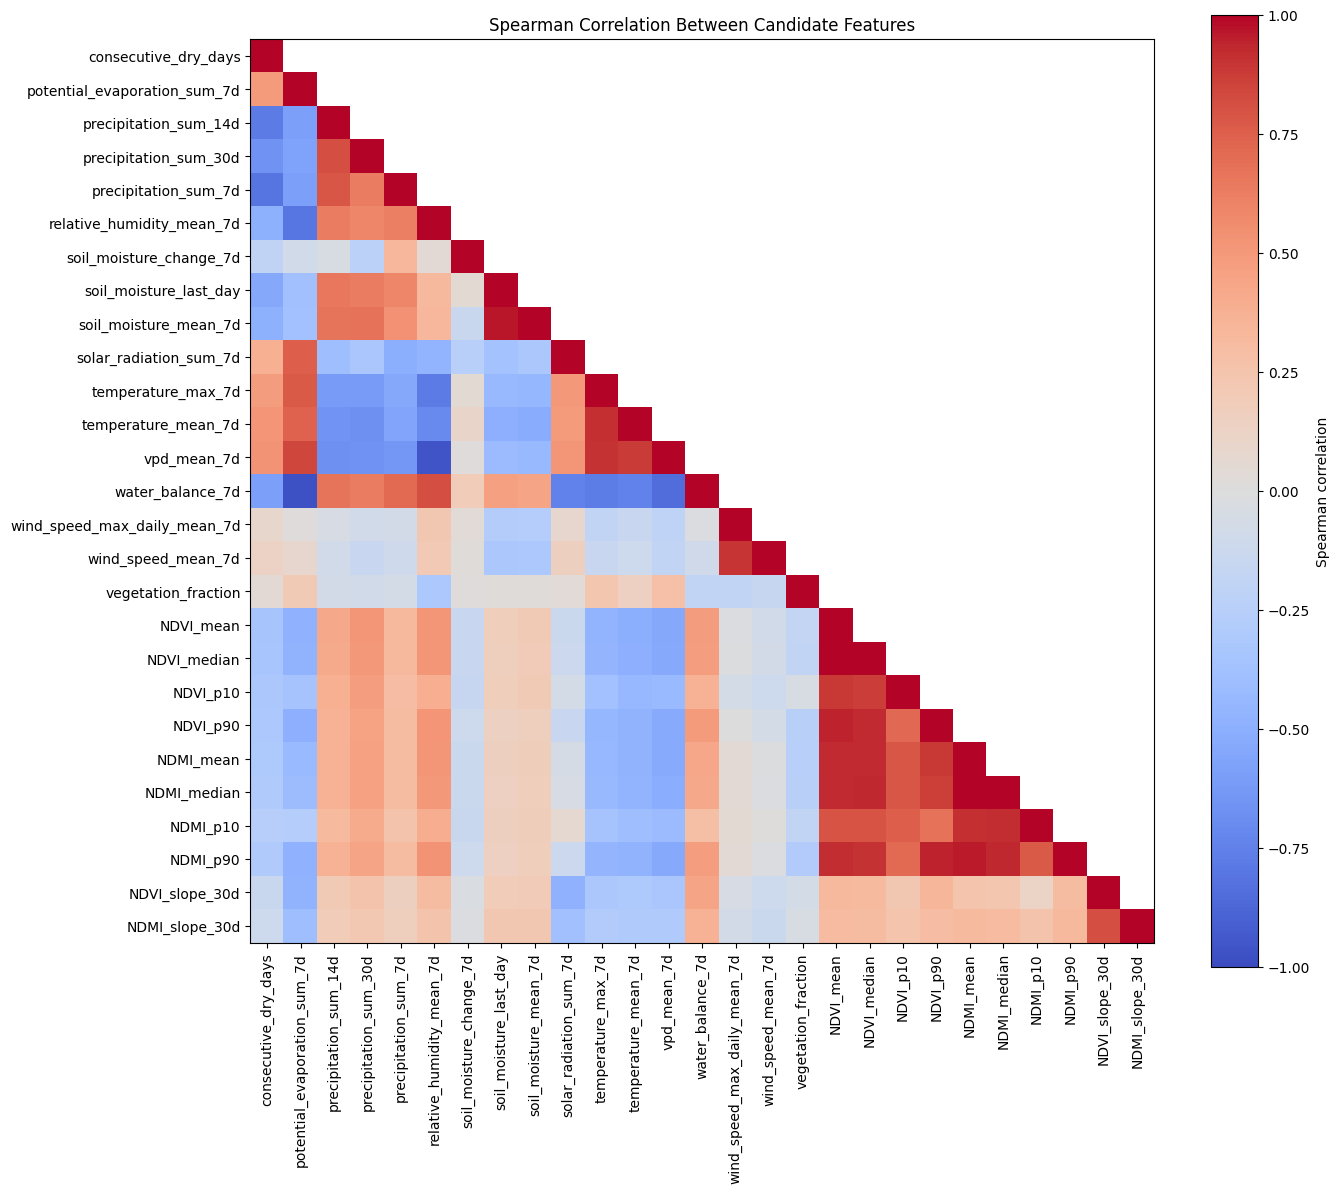

In [168]:
correlation_matrix = train_df[candidate_features].corr(method="spearman")

# mask to hide upper triangle
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool),
    k=1
)

corr_lower = correlation_matrix.mask(mask)

fig, ax = plt.subplots(figsize=(14, 12))

heatmap = ax.imshow(
    corr_lower,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(range(len(candidate_features)))
ax.set_yticks(range(len(candidate_features)))

ax.set_xticklabels(candidate_features, rotation=90)
ax.set_yticklabels(candidate_features)

ax.set_title("Spearman Correlation Between Candidate Features")

fig.colorbar(
    heatmap,
    ax=ax,
    label="Spearman correlation"
)

plt.tight_layout()
plt.show()

### Highly correlated feature pairs

The heatmap reveals several groups of strongly related predictors.

To support feature-selection decisions, particularly for the Logistic Regression model,
pairs with an absolute Spearman correlation of at least **0.80** are identified
explicitly.

A high correlation does not automatically imply that one feature must be removed.
The decision also depends on physical interpretability, model type and whether the
variables represent genuinely distinct processes.

In [169]:
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .rename("spearman_r")
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2"
    })
)

high_corr_pairs["abs_r"] = high_corr_pairs["spearman_r"].abs()

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["abs_r"] >= 0.80
    ]
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs

,feature_1,feature_2,spearman_r,abs_r
0,NDMI_mean,NDMI_median,0.994608,0.994608
1,NDVI_mean,NDVI_median,0.993744,0.993744
2,potential_evaporation_sum_7d,water_balance_7d,-0.975961,0.975961
3,soil_moisture_last_day,soil_moisture_mean_7d,0.964408,0.964408
4,NDMI_mean,NDMI_p90,0.956305,0.956305
5,relative_humidity_mean_7d,vpd_mean_7d,-0.955210,0.955210
6,NDVI_p90,NDMI_p90,0.945297,0.945297
7,NDVI_mean,NDVI_p90,0.941212,0.941212
8,NDMI_median,NDMI_p90,0.933128,0.933128
9,NDVI_median,NDMI_median,0.931803,0.931803


### Implications for model design

Several groups of strongly correlated predictors are present in the dataset.

For the weather-only Logistic Regression model, strong multicollinearity can make
coefficient estimates unstable and complicate their interpretation. A reduced set
of physically interpretable weather predictors will therefore be considered and
evaluated using the Variance Inflation Factor (VIF).

For tree-based models such as XGBoost, multicollinearity is less restrictive.
The complete weather and Sentinel-2 feature sets can therefore be retained
initially, allowing the model to determine which predictors provide useful
non-linear or interaction information.

The correlation analysis is consequently used primarily to guide the design and
interpretation of the Logistic Regression baseline rather than to eliminate
features globally.